# Tier 1: Hand-Tuned Scorecard

**CSCI 575 | Privacy-Preserving Record Linkage**

A weighted sum of per-field similarities, classified by a 0.70 threshold. Weights are assigned by best-guess, with no additional training. Serves as the no-ML baseline that the four ML tiers are compared against.

### Glossary

- **Jaro-Winkler:** A string similarity score in [0, 1] tolerant of typos, transpositions, and shared prefixes. Used here for the five text fields.
- **Exact-match (with normalization):** ZIP, state, and phone are reduced to a standard form (digits-only, or trimmed-and-uppercased) and then compared for equality. Returns 1.0 or 0.0.
- **Threshold:** The cutoff above which a candidate pair is classified as a match. T1 uses 0.70, hand-tuned to sit in the valley between the match and non-match score populations.

In [1]:
from sklearn.model_selection import train_test_split

from utils import (
    load_candidates, build_feature_matrix,
    compute_metrics, print_metrics, save_metrics,
    plot_score_distribution,
    save_example_pair_predictions,
)

THRESHOLD   = 0.70
RANDOM_SEED = 42  

## Field Weights

Last name and DOB get the most weight because they're the most unique. State is likely the most genaric and gets the smallest weights. Weights sum to 1.0.

In [2]:
FIELD_WEIGHTS = {
    'first_name':     0.20,
    'last_name':      0.25,
    'street_address': 0.10,
    'date_of_birth':  0.20,
    'email':          0.15,
    'zip_code':       0.05,
    'state':          0.02,
    'phone':          0.03,
}


## Load Data and Build Feature Matrix

In [3]:
candidates              = load_candidates()
field_similarity_scores = build_feature_matrix(candidates)

print(f'{len(candidates):,} candidate pairs  '
      f'({candidates["is_match"].sum():,} matches, '
      f'{(~candidates["is_match"]).sum():,} non-matches)')

500,000 candidate pairs  (50,000 matches, 450,000 non-matches)


## Score Candidate Pairs

Weighted sum of per-field similarities, classified at a 0.70 threshold. The same 80/20 split is used by T2–T5 so all five tiers report metrics on the same 100k test pairs.

In [4]:
candidates['weighted_score'] = sum(
    FIELD_WEIGHTS[field] * field_similarity_scores[field]
    for field in FIELD_WEIGHTS
)
candidates['predicted_match'] = (candidates['weighted_score'] >= THRESHOLD).astype(int)

labels = candidates['is_match'].astype(int)
_, test_index = train_test_split(
    candidates.index,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=labels,
)
test_candidates = candidates.loc[test_index]

candidates[['rec_id_a', 'rec_id_b', 'is_match', 'weighted_score', 'predicted_match']].head(15)

,rec_id_a,rec_id_b,is_match,weighted_score,predicted_match
0,0,0,True,0.746000,1
1,1,1,True,0.990000,1
2,2,2,True,0.742995,1
3,3,3,True,0.798929,1
4,4,4,True,0.945333,1
5,5,5,True,0.658889,0
6,6,6,True,0.952857,1
7,7,7,True,1.000000,1
8,8,8,True,0.950000,1
9,9,9,True,0.979745,1


## Evaluate

Standard metrics on the 100k held-out test set.

In [5]:
metrics = compute_metrics(
    tier_name        = 'T1_hand_tuned_scorecard',
    true_labels      = test_candidates['is_match'].astype(int),
    predicted_labels = test_candidates['predicted_match'],
    scores           = test_candidates['weighted_score'],
    threshold        = THRESHOLD,
    n_pairs          = len(test_candidates),
)
print_metrics(metrics)

Precision : 0.9992
Recall    : 0.9071
F1        : 0.9509
AUC-ROC   : 0.9950
Threshold : 0.7
N pairs   : 100,000


## Score Distribution

Step histograms of match (green) and non-match (red) scores. Non-matches outnumber matches 9:1. The threshold should sit somewhere in the valley between the two distributions.

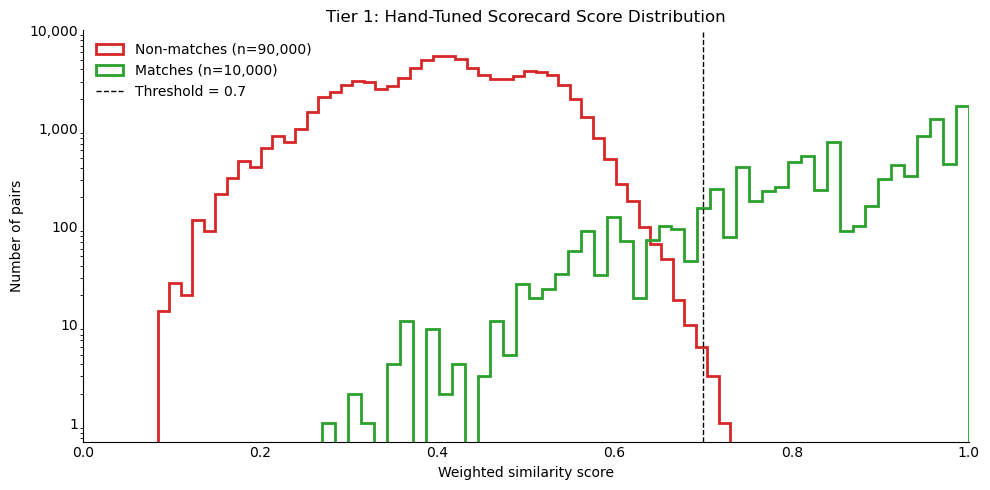

In [6]:
plot_score_distribution(
    match_scores     = test_candidates.loc[test_candidates['is_match'],  'weighted_score'],
    non_match_scores = test_candidates.loc[~test_candidates['is_match'], 'weighted_score'],
    threshold        = THRESHOLD,
    title            = 'Tier 1: Hand-Tuned Scorecard Score Distribution',
    x_label          = 'Weighted similarity score',
    filename         = 'tier1_score_distribution.png',
    legend_loc       = 'upper left',
)

## Save Results

In [7]:
save_metrics(metrics, 'tier1_metrics.csv')
save_example_pair_predictions(candidates, 'T1_hand_tuned_scorecard', 'weighted_score', 'tier1_example_predictions.csv')